# Basic Simulation: Single TX and RX 

### Import Simulation Libraries and Dependncies 

In [1]:
# Import simulation libraries 
import mitsuba as mi
mi.set_variant("cuda_ad_mono_polarized"); 

import numpy as np
import sionna.rt
from sionna.rt import load_scene, PlanarArray, Transmitter, Receiver, Camera, PathSolver, RadioMapSolver, subcarrier_frequencies

# Load configs 
from generate_raynet_mumimo_dataset_v2 import CONFIG 

jitc_llvm_init(): LLVM API initialization failed ..


ModuleNotFoundError: No module named 'generate_raynet_mumimo_dataset_v2'

### Add Transmitter and Receiver 

In [8]:
# Initialize the scene 
scene = load_scene(sionna.rt.scene.simple_reflector); 
scene.frequency = CONFIG["frequency_hz"]; 

# Set up TX and RX 
scene.tx_array = PlanarArray(
    num_rows=1,
    num_cols=1,
    vertical_spacing=0.5,
    horizontal_spacing=0.5,
    pattern="tr38901",
    polarization="V",
); 

scene.rx_array = PlanarArray(
    num_rows=1,
    num_cols=1,
    vertical_spacing=0.5,
    horizontal_spacing=0.5,
    pattern="dipole",
    polarization="V",
); 

tx = Transmitter(
    name="tx",
    position=CONFIG["tx_position"],
); 

scene.add(tx); 

### Load the scene

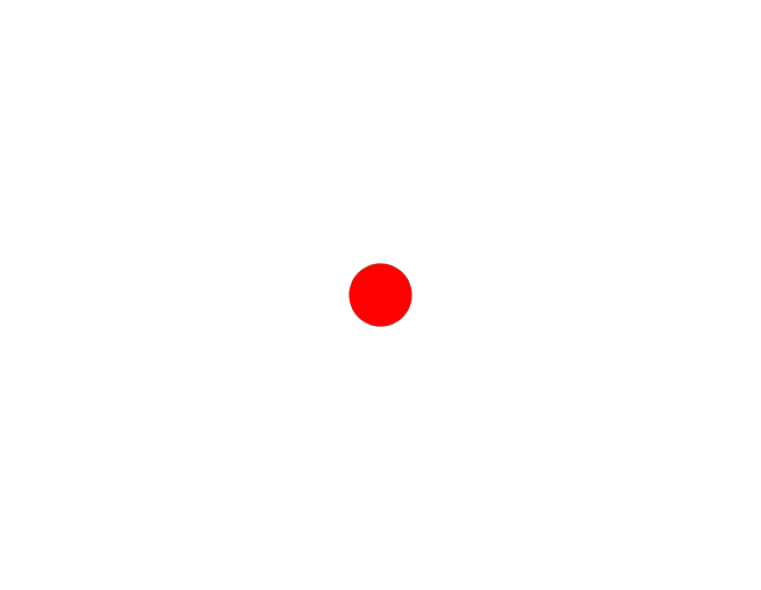

In [9]:
# Load scene sim 
scene.preview(); 

# Create cam with config 
my_cam = Camera(position = [10, 10, 0], look_at = CONFIG["tx_position"]); 

# Render scene with cam 
scene.render(camera = my_cam, resolution = [650, 500], num_samples = 512); 